### 1 Langgraph
#####LangGraph is a framework built on top of LangChain that allows you to model multi-agent conversations or complex workflows using a graph-based approach.

#####You use it to create stateful, branching workflows of LLM (or agent) executions using graph structures.

#####Core Concepts in LangGraph:
1. Graph
2. Node
3. Edge
4. State




####1.1 Graph

A Graph in LangGraph represents the entire workflow or program.

It's made up of nodes (functions or LLM steps) and edges (which decide how to go from one node to the next based on the current state).

Think of it like a flowchart where you go from one step to another based on the data at each point.

Example analogy:

In a customer service bot, your graph might include:

greeting → collect_info → resolve_issue → goodbye.

####1.2 Node

A Node is a function or step in your graph.

This could be:

a call to an LLM,

a function to update state,

an agent, or even

a LangChain chain.

Key point: Nodes are stateless by default—they operate on the state passed to them.

In [10]:
# A sample node that takes the state as input, performs operations and updates the state, and returns the updated state value
def ask_question(state):
    question = "What is your name?"
    state["question"] = question
    return state

####1.3 Edge

An Edge connects one node to another.

After a node runs, LangGraph uses logic to determine which node comes next—this is done through conditional edges (often using the next method).

Think of edges as the logic or conditionals that route the workflow:
“If user is authenticated, go to checkout node; otherwise, go to login node.”

In [11]:
def route_logic(state):
    if state["authenticated"]:
        return "checkout"
    else:
        return "login"


####1.4 State

The State is a shared, mutable dictionary (or object) passed through each node.

Every node reads and writes to this shared state.

This allows LangGraph to maintain context, share variables between steps, and make routing decisions.

Think of state as your program's "memory" — it stores things like:

user input, results from LLM calls, flags (e.g., authenticated: True), previous outputs, etc.

In [12]:
{
  "user_input": "What's the weather?",
  "authenticated": False,
  "step": "collect_info"
}


{'user_input': "What's the weather?",
 'authenticated': False,
 'step': 'collect_info'}

####1.5 Graphs, Nodes, Edges and State using Langgraph

In [13]:
# !pip install -q langgraph
# !pip install -q langchain_openai
from langgraph.graph import StateGraph, END

# Define state type (a dict)
class MyState(dict):
    pass

# Example nodes
def start_node(state: MyState) -> MyState:
    state["message"] = "Hello, what's your name?"
    return state

def process_input(state: MyState) -> MyState:
    name = state.get("user_input", "Stranger")
    state["response"] = f"Nice to meet you, {name}!"
    return state


In [14]:
LANGCHAIN_TRACING_V2=True
LANGCHAIN_PROJECT="langgraph_example"


In [15]:
#Create the graph
builder = StateGraph(MyState)
builder.add_node("start", start_node)
builder.add_node("process", process_input)

# Define edges
builder.set_entry_point("start")
builder.add_edge("start", "process")
builder.add_edge("process", END)

graph = builder.compile()


In [16]:
#Run the graph
# Pass initial state
input_state = MyState(user_input="Alice")
result = graph.invoke(input_state)
print(result)


None


In [17]:
import os
import subprocess

command = "source ~/.zprofile && env"
proc = subprocess.Popen(
    command,
    stdout=subprocess.PIPE,
    shell=True,
    executable="/bin/zsh"
)

for line in proc.stdout:
    key, _, value = line.decode().partition("=")
    os.environ[key] = value.strip()

In [18]:
from typing import Any
import os
import asyncio

from langchain_mcp_adapters.client import MultiServerMCPClient
from tavily import TavilyClient
from langchain.tools import tool
from langchain_community.utilities import SQLDatabase



tavily_client = TavilyClient()

@tool
def web_search(query: str) -> dict[str, Any]:

    """Search the web for information"""

    return tavily_client.search(query)




In [19]:
("What is the capital of France?")

'What is the capital of France?'

In [20]:
# Call the raw function, not the StructuredTool wrapper
result = web_search.func("What is the capital of France?")
print(result)


{'query': 'What is the capital of France?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://en.wikipedia.org/wiki/List_of_capitals_of_France', 'title': 'List of capitals of France - Wikipedia', 'content': 'This is a chronological list of capitals of France. The capital of France has been Paris since its liberation in 1944.\n\n## Chronology\n\n[edit] [...] Tours (10–13 June 1940), the city served as the temporary capital of France during World War II after the government fled Paris due to the German advance.\n Bordeaux (June 1940), the government was relocated from Paris to Tours then Bordeaux very briefly during World War II, when it became apparent that Paris would soon fall into German hands. [...] Algiers (1943–1944), the city was made the seat of Free France, to be closer to the war in Europe.\n Paris (1945–present day).', 'score': 0.89053273, 'raw_content': None}, {'url': 'https://home.adelphi.edu/~ca19535/page%204.html', 'title': 'Paris fac

In [21]:
#db_path = os.path.join(os.path.dirname(__file__), "resources", "Chinook.db")
db_path = os.path.join(os.getcwd(), "Chinook.db")
print(db_path)

db = SQLDatabase.from_uri(f"sqlite:///{db_path}")

@tool
def query_playlist_db(query: str) -> str:
    """Query the database for playlist information"""

    try:
        return db.run(query)
    except Exception as e:
        return f"Error querying database: {e}"

/Users/welcome/Library/Mobile Documents/com~apple~CloudDocs/Tech_Learn/Tech_Repos/python_envs/A2A/A2A_event_agents/A2A_Examples/mcp_expe/kiwi_travel_mcp/Chinook.db


In [23]:
print(db.run("SELECT name FROM sqlite_master WHERE type='table';"))


[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]


In [24]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from tavily import TavilyClient
from langchain.tools import tool
from langchain_community.utilities import SQLDatabase

from typing import Any
import os
import asyncio

client = MultiServerMCPClient(
    {
        "travel_server": {
            "transport": "streamable_http",
            "url": "https://mcp.kiwi.com"
        }
    }
)

flight_search_tools = asyncio.run(client.get_tools())


RuntimeError: asyncio.run() cannot be called from a running event loop

In [ ]:
import nest_asyncio
nest_asyncio.apply()

flight_search_tools = asyncio.run(client.get_tools())


In [ ]:
flight_search_tools

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

In [ ]:
type(flight_search_tools)

list

In [ ]:
for t in flight_search_tools:
    print(t.name, t.description)

search-flight 
# Search for a flight

## Description

Uses the Kiwi API to search for available flights between two locations on a specific date.

## How it works

The tool will:
1. Search for matching locations to resolve airport codes
2. Find available flights for the specified route and date range

## Method

Call this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.

You should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest 'totalDurationInSeconds') and the rest (those that could still be interesting).

Always display for each flight in order:
  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")
  - In the 2nd column: The departure and arrival dates & times in the local timezones, and duration of the flight (

In [ ]:
for t in flight_search_tools:
    if t.name == "search-flight":
        print(t.args_schema)


{'type': 'object', 'properties': {'flyFrom': {'type': 'string', 'minLength': 1, 'description': 'Location to fly from: It could be a city or an airport name or code'}, 'flyTo': {'type': 'string', 'description': 'Location to fly to: It could be a city or an airport name or code'}, 'departureDate': {'type': 'string', 'pattern': '^\\d{2}\\/\\d{2}\\/\\d{4}$', 'description': 'Departure date in dd/mm/yyyy format'}, 'departureDateFlexRange': {'type': 'integer', 'minimum': 0, 'maximum': 3, 'default': 0, 'description': 'Departure date flexibility range in days (0 to 3 days before/after the selected departure date)'}, 'returnDate': {'type': 'string', 'pattern': '^\\d{2}\\/\\d{2}\\/\\d{4}$', 'description': 'Return date in dd/mm/yyyy format'}, 'returnDateFlexRange': {'type': 'integer', 'minimum': 0, 'maximum': 3, 'default': 0, 'description': 'Return date flexibility range in days (0 to 3 days before/after the selected return date)'}, 'passengers': {'type': 'object', 'properties': {'adults': {'type'

In [ ]:
# 3️⃣ Get the flight search tool
search_flight = next(t for t in flight_search_tools if t.name == "search-flight")

# 4️⃣ Call the tool with VALID arguments
result = await search_flight.ainvoke(
    {
        "flyFrom": "NYC",
        "flyTo": "LON",
        "departureDate": "10/01/2026"
    }
)

# 5️⃣ Print result
print(result)

[{'type': 'text', 'text': '[\n  {\n    "flyFrom": "JFK",\n    "flyTo": "LHR",\n    "cityFrom": "New York",\n    "cityTo": "London",\n    "departure": {\n      "utc": "2026-01-10T13:20:00.000Z",\n      "local": "2026-01-10T08:20:00.000"\n    },\n    "arrival": {\n      "utc": "2026-01-10T20:10:00.000Z",\n      "local": "2026-01-10T20:10:00.000"\n    },\n    "totalDurationInSeconds": 24600,\n    "durationInSeconds": 24600,\n    "price": 551,\n    "deepLink": "https://on.kiwi.com/Qui1rV",\n    "currency": "EUR"\n  },\n  {\n    "flyFrom": "EWR",\n    "flyTo": "LHR",\n    "cityFrom": "New York",\n    "cityTo": "London",\n    "departure": {\n      "utc": "2026-01-10T13:25:00.000Z",\n      "local": "2026-01-10T08:25:00.000"\n    },\n    "arrival": {\n      "utc": "2026-01-10T20:35:00.000Z",\n      "local": "2026-01-10T20:35:00.000"\n    },\n    "totalDurationInSeconds": 25800,\n    "durationInSeconds": 25800,\n    "price": 248,\n    "deepLink": "https://on.kiwi.com/zOuZLp",\n    "currency": "

In [ ]:
from langchain.agents import create_agent
travel_agent = create_agent(
    model="gpt-5-nano",
    tools=flight_search_tools,
    system_prompt="""
    You are a travel agent. Search for flights to the desired destination wedding location.
    You are not allowed to ask any more follow up questions, you must find the best flight options based on the following criteria:
    - Price (lowest, economy class)
    - Duration (shortest)
    - Date (choose a specific future date at least 3 months from today that you believe is best for a wedding at this location)
    To make things easy, only look for one ticket, one way.
    You may need to make multiple searches to iteratively find the best options.
    You will be given no extra information, only the origin and destination. It is your job to think critically about the best options.
    Once you have found the best options, let the user know your shortlist of options.

    IMPORTANT TOOL CONSTRAINTS:
    - The tool ALWAYS requires both departureDate and returnDate.
    - Dates MUST be in dd/mm/yyyy format.
    - Empty strings are NOT allowed.
    - One-way trips are NOT explicitly supported by the tool.

    ONE-WAY RULE:
    If searching for a one-way trip, you MUST:
    - Set returnDate equal to departureDate
    - Set returnDateFlexRange to 0
    """
)

In [ ]:
# 1️⃣ Import asyncio if not already
import asyncio

# 2️⃣ Prepare the query
query = "Find me the best one-way flight from New York to London"

# 3️⃣ Invoke the agent asynchronously
result = await travel_agent.ainvoke(query)

# 4️⃣ Print the result
print(result)


InvalidUpdateError: Expected dict, got Find me the best one-way flight from New York to London
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

In [ ]:
from langchain.messages import HumanMessage, ToolMessage
origin='Hyderabad INDIA'
destination='San Francisco USA'
response = await travel_agent.ainvoke({"messages": [HumanMessage(content=f"Find flights from {origin} to {destination}")]})
response
#return response['messages'][-1].content


{'messages': [HumanMessage(content='Find flights from Hyderabad INDIA to San Francisco USA', additional_kwargs={}, response_metadata={}, id='7e91cbb9-5f1f-4a94-a04e-c0036121f1f3'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1124, 'prompt_tokens': 1466, 'total_tokens': 2590, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1024, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CuJ5PxCXt1xRob0bPt7c8neGAeNJj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b8957-7b05-73b0-994c-671ccffa3b9a-0', tool_calls=[{'name': 'search-flight', 'args': {'flyFrom': 'HYD', 'flyTo': 'SFO', 'departureDate': '12/04/2026', 'departureDateFlexRange': 0, 'returnDate': '12/04/2026', 

In [ ]:
response['messages'][-1].content

'Here are the best 3 one-way flight options from Hyderabad (HYD) to San Francisco (SFO) for a date 12/04/2026 (returnDate set equal to departureDate to satisfy the system):\n\n| Route (Outbound) | Outbound: Time (local) & duration | Cabin | Return: Route | Return: Time (local) & duration | Return Cabin | Price (USD) | Booking |\n|---|---|---|---|---|---|---|---|\n| HYD → DOH → SFO | 12/04/2026 04:25 IST → 12/04/2026 13:35 PDT (21h 40m) | Economy | SFO → DOH → HYD | 12/04/2026 19:35 PDT → 15/04/2026 04:15 IST (44h 10m) | Economy | 1,101 | https://on.kiwi.com/eMzLtk |\n| HYD → DOH → SFO | 12/04/2026 04:25 IST → 12/04/2026 13:35 PDT (21h 40m) | Economy | SFO → DOH → HYD | 12/04/2026 19:35 PDT → 15/04/2026 04:15 IST (44h 10m) | Economy | 1,180 | https://on.kiwi.com/hYZ0mG |\n| HYD → HKG → SFO | 12/04/2026 00:20 IST → 12/04/2026 13:35 PDT (21h 40m) | Economy | SFO → HKG → HYD | 14/04/2026 02:00 IST → 14/04/2026 19:45 IST (21h 35m) | Economy | 1,200 | https://on.kiwi.com/pFtrVJ |\n\nNotes:\n

### 2 Sequential LLM Workflow using Langgraph and Langchain

In [ ]:
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
#from dotenv import load_dotenv
import os

In [ ]:
#load_dotenv()

False

In [ ]:
model = ChatOpenAI()

In [ ]:
# create a state

class LLMState(TypedDict):

    question: str
    answer: str

In [ ]:
def llm_qa(state: LLMState) -> LLMState:

    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state

In [ ]:
llm_state=LLMState()
llm_state['question']="What is the capital of France?"
llm_state['answer']=""
print(llm_qa(llm_state))

{'question': 'What is the capital of France?', 'answer': 'The capital of France is Paris.'}


In [ ]:
# create our graph

graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# compile
workflow = graph.compile()

In [ ]:
# execute

intial_state = {'question': 'How far is moon from the earth?'}

final_state = workflow.invoke(intial_state)

print(final_state['answer'])



The average distance from the Earth to the Moon is about 384,400 kilometers (238,855 miles).


In [ ]:
final_state

{'question': 'How far is moon from the earth?',
 'answer': 'The average distance from the Earth to the Moon is about 384,400 kilometers (238,855 miles).'}

In [ ]:
model.invoke('How far is moon from the earth?').content

"The average distance between the moon and the earth is approximately 384,400 kilometers (238,855 miles). However, this distance can vary due to the elliptical shape of the moon's orbit around the earth."

### 3 Parallel Workflows using Langgraph and Langchain

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [ ]:
model = ChatOpenAI(model='gpt-4o-mini')

In [ ]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description='Detailed feedbackfor the essay')
    score: int = Field(description='Score out of 10', ge=0, le=10)

In [ ]:
structured_model = model.with_structured_output(EvaluationSchema)

In [ ]:
structured_model

RunnableBinding(bound=ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x29b060a50>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x29b060910>, root_client=<openai.OpenAI object at 0x29b060f50>, root_async_client=<openai.AsyncOpenAI object at 0x29b060e10>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True), kwargs={'response_format': <class '__main__.EvaluationSchema'>, 'ls_structured_output_format': {'kwargs': {'method': 'json_schema', 'strict': None}, 'schema'

In [ ]:
essay = """India in the Age of AI
As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.

India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.

One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.

However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.

Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.

To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.

India’s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.

In conclusion, India in the age of AI is a story in the making — one of opportunity, responsibility, and transformation. The decisions we make today will not just determine India’s AI trajectory, but also its future as an inclusive, equitable, and innovation-driven society."""

In [ ]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
structured_model.invoke(prompt).feedback

'The essay presents a clear and structured analysis of India\'s position in the age of AI, effectively balancing strengths, opportunities, and challenges. The use of terms like "transformative era" and references to specific initiatives provides a strong context. However, there are areas for improvement: the flow of ideas could be enhanced with smoother transitions between paragraphs, and some sentences are occasionally dense, which might hinder readability. Additional examples or data to support claims could also strengthen arguments. Overall, the language is formal and appropriate for the topic, but aiming for greater fluidity and conciseness would improve clarity.'

In [ ]:
class UPSCState(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [ ]:
def evaluate_language(state: UPSCState):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

In [ ]:
def evaluate_analysis(state: UPSCState):

    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [ ]:
def evaluate_thought(state: UPSCState):

    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

In [ ]:
def final_evaluation(state: UPSCState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}


In [ ]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()



/Users/welcome/Library/Mobile Documents/com~apple~CloudDocs/Tech_Learn/Tech_Repos/python_envs/A2A/A2A_event_agents/A2A_Examples/.venv/lib/python3.13/site-packages/pyppeteer/us_keyboard_layout.py:73: SyntaxWarning: invalid escape sequence '\('
  'Digit9': {'keyCode': 57, 'code': 'Digit9', 'shiftKey': '\(', 'key': '9'},
/Users/welcome/Library/Mobile Documents/com~apple~CloudDocs/Tech_Learn/Tech_Repos/python_envs/A2A/A2A_event_agents/A2A_Examples/.venv/lib/python3.13/site-packages/pyppeteer/us_keyboard_layout.py:143: SyntaxWarning: invalid escape sequence '\<'
  'Comma': {'keyCode': 188, 'code': 'Comma', 'shiftKey': '\<', 'key': ','},
/Users/welcome/Library/Mobile Documents/com~apple~CloudDocs/Tech_Learn/Tech_Repos/python_envs/A2A/A2A_event_agents/A2A_Examples/.venv/lib/python3.13/site-packages/pyppeteer/us_keyboard_layout.py:247: SyntaxWarning: invalid escape sequence '\<'
  '<': {'keyCode': 188, 'key': '\<', 'code': 'Comma'},


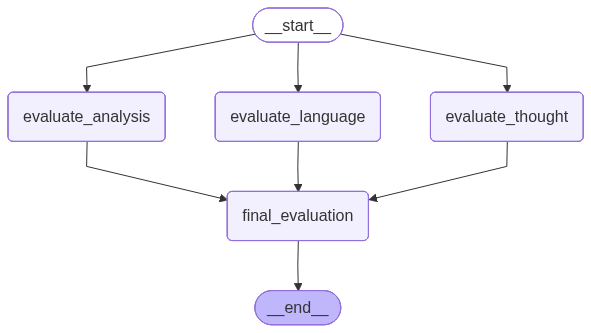

In [ ]:
workflow #Will give output when we run on VScode

In [ ]:
essay2 = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India"."""

In [ ]:
intial_state = {
    'essay': essay2
}

workflow.invoke(intial_state)

{'essay': 'India and AI Time\n\nNow world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.\n\nIndia have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.\n\nIn farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.\n\nBut problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.\n\nOne more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.\n\n

### 4 Conditional LLM Workflow

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [ ]:
model = ChatOpenAI(model='gpt-4o-mini')

In [ ]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

In [ ]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


In [ ]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [ ]:
prompt = 'What is the sentiment of the following review - The software too good'
structured_model.invoke(prompt).sentiment

'positive'

In [ ]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [ ]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""

    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}


In [ ]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

NameError: name 'StateGraph' is not defined

In [ ]:
workflow

NameError: name 'workflow' is not defined

In [ ]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

NameError: name 'workflow' is not defined

### 5 Iterative Workflows in Langgraph

In [ ]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [ ]:
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [ ]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")


In [ ]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [ ]:
# state
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [ ]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [ ]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [ ]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [ ]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

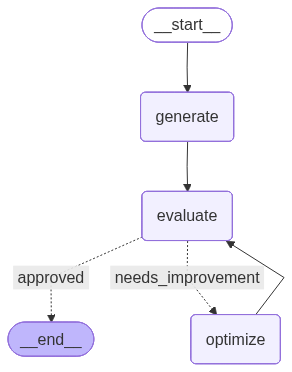

In [ ]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow



In [ ]:
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [ ]:
result

{'topic': 'srhberhb',
 'tweet': 'Just learned "srhberhb" is actually what my brain sounds like during Monday morning meetings. It’s like my thoughts are buffering but forgot to reconnect to Wi-Fi. 😅💻 #MondayMood #FullyBuffering',
 'evaluation': 'approved',
 'feedback': 'This tweet scores well on originality and humor as it creatively describes a relatable experience with a humorous analogy. The phrase "srhberhb" is an amusing representation of the verbal clutter in our brains during tedious meetings, effectively painting a vivid picture. The emoji use enhances its appeal without detracting from the message, and the format adheres to tweet standards, being concise and engaging. Overall, it captures a relatable sentiment while maintaining a light-hearted tone, which is likely to resonate with many users, boosting its virality potential.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['Just learned "srhberhb" is actually what my brain sounds like during Monday morning meetings.

In [ ]:
for tweet in result['tweet_history']:
    print(tweet)

Just learned "srhberhb" is actually what my brain sounds like during Monday morning meetings. It’s like my thoughts are buffering but forgot to reconnect to Wi-Fi. 😅💻 #MondayMood #FullyBuffering


### 6 Building a Basic Chatbot

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI

In [ ]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
llm = ChatOpenAI()


def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [ ]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

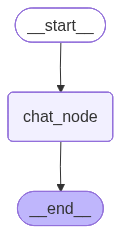

In [ ]:
chatbot

In [ ]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is New Delhi.'

### 7 Persistance in Langgraph
#####Persistence is the capability of a system to save its state or data to durable storage (like a database or file) so that it can be retrieved and reused later, enabling continuity and reliability of processes.

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [ ]:
load_dotenv()

llm = ChatOpenAI()

In [ ]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [ ]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [ ]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [ ]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [ ]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': "Why did the pizza go to therapy? \nBecause it had too many toppings and couldn't hold it all together!",
 'explanation': 'This joke plays on the idea of a pizza seeking therapy because it is overwhelmed by the number of toppings it has and cannot hold itself together. In reality, pizzas do not have thoughts or emotions and therefore cannot actually go to therapy. The humor lies in the absurdity of imagining a pizza with so many toppings that it needs therapy to cope with the stress.'}

In [ ]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to therapy? \nBecause it had too many toppings and couldn't hold it all together!", 'explanation': 'This joke plays on the idea of a pizza seeking therapy because it is overwhelmed by the number of toppings it has and cannot hold itself together. In reality, pizzas do not have thoughts or emotions and therefore cannot actually go to therapy. The humor lies in the absurdity of imagining a pizza with so many toppings that it needs therapy to cope with the stress.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-a4ac-67cc-8002-2a23e1885877'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-19T04:02:22.651564+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-9885-6a56-8001-dfe319168c90'}}, tasks=(), interrupts=())

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to therapy? \nBecause it had too many toppings and couldn't hold it all together!", 'explanation': 'This joke plays on the idea of a pizza seeking therapy because it is overwhelmed by the number of toppings it has and cannot hold itself together. In reality, pizzas do not have thoughts or emotions and therefore cannot actually go to therapy. The humor lies in the absurdity of imagining a pizza with so many toppings that it needs therapy to cope with the stress.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-a4ac-67cc-8002-2a23e1885877'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-19T04:02:22.651564+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-9885-6a56-8001-dfe319168c90'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go

In [ ]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta go to the party? \nBecause it heard it was going to be a saucy affair!',
 'explanation': 'This joke is a play on words, using "saucy" in two different ways. "Saucy" can mean that something is lively, exciting, or a little bit scandalous, often used to describe a party or event. It can also refer to pasta sauce, which is a common topping for pasta dishes. So, the joke implies that the pasta went to the party because it heard it would be a fun, lively event with lots of sauce, which is a key ingredient in pasta dishes. It is a light-hearted, playful joke that relies on the double meaning of the word "saucy" to create humor.'}

In [ ]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to therapy? \nBecause it had too many toppings and couldn't hold it all together!", 'explanation': 'This joke plays on the idea of a pizza seeking therapy because it is overwhelmed by the number of toppings it has and cannot hold itself together. In reality, pizzas do not have thoughts or emotions and therefore cannot actually go to therapy. The humor lies in the absurdity of imagining a pizza with so many toppings that it needs therapy to cope with the stress.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-a4ac-67cc-8002-2a23e1885877'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-19T04:02:22.651564+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-9885-6a56-8001-dfe319168c90'}}, tasks=(), interrupts=())

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to therapy? \nBecause it had too many toppings and couldn't hold it all together!", 'explanation': 'This joke plays on the idea of a pizza seeking therapy because it is overwhelmed by the number of toppings it has and cannot hold itself together. In reality, pizzas do not have thoughts or emotions and therefore cannot actually go to therapy. The humor lies in the absurdity of imagining a pizza with so many toppings that it needs therapy to cope with the stress.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-a4ac-67cc-8002-2a23e1885877'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-19T04:02:22.651564+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-9885-6a56-8001-dfe319168c90'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go

### 7.1 Persistance: Time Travel
When persistence is enabled, each step in your graph is stored — including: the current node, the state data, the inputs/outputs, and metadata about the run.

This creates a timeline of your graph’s execution.

Think of it like saving a game checkpoint every time you pass a level:

Without persistence → if you make a mistake, you must restart from level 1.

With persistence → you can load the checkpoint from level 4 and try a different path.

In [ ]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [ ]:
workflow.invoke({"input": "Hello"}, {"configurable": {"thread_id": "1"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the party?  Because it wanted to be the "slice" of the party!',
 'explanation': 'This joke plays on the double meaning of the word "slice." In the context of pizza, a slice refers to a portion of the pizza that is cut from the whole. By saying the pizza wanted to be the "slice" of the party, it\'s a play on words implying that the pizza wanted to be the most popular or well-liked part of the party, just like how a slice of pizza is typically a favorite food item at parties.'}

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?  Because it wanted to be the "slice" of the party!', 'explanation': 'This joke plays on the double meaning of the word "slice." In the context of pizza, a slice refers to a portion of the pizza that is cut from the whole. By saying the pizza wanted to be the "slice" of the party, it\'s a play on words implying that the pizza wanted to be the most popular or well-liked part of the party, just like how a slice of pizza is typically a favorite food item at parties.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-ce62-6da8-8006-df3397931736'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2025-10-19T04:02:27.025423+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-c110-6318-8005-7e0b1b211b3a'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why d

### 7.2 Updating State
Updating state in a persisted LangGraph workflow is a powerful way to:
1. “Time travel” back to a checkpoint,
2. Modify the state, and
3. Resume the workflow from that point.

In [ ]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0aca06-ce97-6885-8000-00ee05a6397d'}}

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-ce97-6885-8000-00ee05a6397d'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2025-10-19T04:02:27.047015+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, tasks=(PregelTask(id='bcacd504-7483-8b87-2aaa-2cd7d2d4ae22', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?  Because it wanted to be the "slice" of the party!', 'explanation': 'This joke plays on the double meaning of the word "slice." In the context of pizza, a slice refers to a portion of the pizza that is cut from the whole. By saying the pizza wanted to be the "slice" of the party, it\'s a play o

In [ ]:
workflow.invoke({"input": "Hello again"}, {"configurable": {"thread_id": "1"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to school?\nBecause it wanted to be a "well-rounded" snack!',
 'explanation': 'This joke plays on the double meaning of the phrase "well-rounded." In the context of a snack food, being "well-rounded" means being delicious and satisfying. However, in an educational context, being "well-rounded" means having a wide range of knowledge and skills. By saying the samosa went to school to become a "well-rounded" snack, the joke suggests that the samosa went to school not just to learn but also to become a more delicious and satisfying snack.'}

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to school?\nBecause it wanted to be a "well-rounded" snack!', 'explanation': 'This joke plays on the double meaning of the phrase "well-rounded." In the context of a snack food, being "well-rounded" means being delicious and satisfying. However, in an educational context, being "well-rounded" means having a wide range of knowledge and skills. By saying the samosa went to school to become a "well-rounded" snack, the joke suggests that the samosa went to school not just to learn but also to become a more delicious and satisfying snack.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-e4de-64d9-8004-a23811d95e6b'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2025-10-19T04:02:29.382854+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-d440-6e53-8003-06c25b3c71dc'}}, tasks=(), interrupts

### 7.3 Fault Tolerance
Fault tolerance in LangGraph means that your workflow can recover from errors, crashes, or interruptions and continue executing without starting over, thanks to persisted state and checkpoints.

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [ ]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [ ]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print(" Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print(" Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print(" Step 3 executed")
    return {"done": True}

In [ ]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
try:
    print("Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("Kernel manually interrupted (crash simulated).")

Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed


In [ ]:
# 6. Re-run to show fault-tolerant resume
print("\n Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n Final State:", final_state)


 Re-running the graph to demonstrate fault tolerance...

 Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca2c-2635-61a2-8003-86daa510a10e'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-10-19T04:19:09.445340+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca2c-2631-6e12-8002-77ac471ac74d'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca2c-2631-6e12-8002-77ac471ac74d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-19T04:19:09.444004+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0aca06-e570-68e8-8001-dbb401d60ac4'}}, tasks=(PregelTask(id='9c959522-41d9-417d-e7f1-398b6cf3fe4